# Figure 1 & Host Supplements

- **Figure 1** — MCC tree colored by host state (cattle / domestic avian / wild avian)
- **S1** — Combined host + location phylogeny with TX and UT subclade zooms
- **S2** — Host transition counts (15-row violin from posterior)

In [1]:
import baltic as bt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from matplotlib.collections import LineCollection
from matplotlib.path import Path as MplPath
from datetime import datetime, timedelta
from pathlib import Path
from scipy.stats import gaussian_kde

# Paths
PROJ_ROOT = Path("../..").resolve()
PAPER_DIR = PROJ_ROOT / "paper"
PRIVATE_DIR = PROJ_ROOT / "2026_b313_phylogeography_private"
FIT_DIR = PRIVATE_DIR / "xml/host_only_analysis_updated/FIT"
BIT_DIR = PRIVATE_DIR / "xml/host_only_analysis_updated/BIT"
FIG_DIR = PAPER_DIR / "final/figures"
HIPSTR_TREE = FIT_DIR / "host_only_corrected_1358taxa.markov.hipstr.tree"
MAIN_1102_LOG = FIT_DIR / "host_only_corrected_1358taxa.markov.log"
SUBSAMPLED_551_LOG = FIT_DIR / "host_only_1358_downsample_551c.markov.log"
SUBSAMPLED_275_LOG = FIT_DIR / "host_only_1358_downsample_275c.markov.log"
SUBSAMPLED_137_LOG = FIT_DIR / "host_only_1358_downsample_137c.markov.log"
MAIN_1102_JUMPS_LOG = FIT_DIR / "host_only_corrected_1358taxa.markov.host.jumpHistory.log"
SUBSAMPLED_551_JUMPS_LOG = FIT_DIR / "host_only_1358_downsample_551c.markov.host.jumpHistory.log"
SUBSAMPLED_275_JUMPS_LOG = FIT_DIR / "host_only_1358_downsample_275c.markov.host.jumpHistory.log"
SUBSAMPLED_137_JUMPS_LOG = FIT_DIR / "host_only_1358_downsample_137c.markov.host.jumpHistory.log"

TRANS_CSV = BIT_DIR / "host_only_corrected_1358taxa.markov.empirical.BIT.default.copy.merged.transitions.csv"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Host colors (consistent across all panels)
STATE_COLORS = {"cattle": "lightgrey", "domestic_avian": "#C7395A", "wild_avian": "#2A9DC0"}
STATE_LABELS = {"cattle": "Cattle", "domestic_avian": "Domestic avian", "wild_avian": "Wild avian"}

# Location colors (S1)
LOC_COLORS = {
    "USA-CA": "#ff7f00", "USA-TX": "#e41a1c", "USA-ID": "#7b3294",
    "USA-CO": "#2166ac", "USA-IA": "#1b9e77", "USA-MN": "#00838f",
    "USA-MI": "#8c6d31", "USA-OH": "#c51b7d", "USA-NM": "#b2abd2",
    "USA-WY": "#a6d854", "USA-SD": "#fc8d62", "USA-KS": "#ffd92f",
    "USA-UT": "#e5c494", "USA-NE": "#b3b3b3", "USA-OK": "#d9d9d9",
    "USA-NC": "#66c2a5", "USA-OR": "#8da0cb",
}

# Font setup
import matplotlib
for font in ["Arial", "Helvetica", "DejaVu Sans"]:
    try:
        matplotlib.font_manager.findfont(font, fallback_to_default=False)
        plt.rcParams["font.family"] = "sans-serif"
        plt.rcParams["font.sans-serif"] = [font]
        break
    except ValueError:
        continue

plt.rcParams.update({
    "axes.labelsize": 9, "axes.titlesize": 10,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "legend.fontsize": 7, "figure.dpi": 300,
    "savefig.dpi": 300, "savefig.bbox": "tight",
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

In [2]:
def height_to_date(tree_obj, origin_date):
    """Return a function that converts tree height to matplotlib datenum."""
    def h2d(h):
        return mdates.date2num(origin_date + timedelta(days=h * 365.25))
    return h2d


def get_origin_date(tree):
    """Compute origin date from first tip's date and height."""
    tips = tree.getExternal()
    parts = tips[0].name.split("|")
    ref_date = datetime.strptime(parts[4], "%Y-%m-%d")
    return ref_date - timedelta(days=tips[0].height * 365.25)


def hpd_interval(samples, credible_mass=0.95):
    sorted_samples = np.sort(samples)
    n = len(sorted_samples)
    interval_size = int(np.ceil(credible_mass * n))
    widths = sorted_samples[interval_size:] - sorted_samples[:n - interval_size]
    best = np.argmin(widths)
    return sorted_samples[best], sorted_samples[best + interval_size]


def build_children_map(tree):
    obj_set = set(id(n) for n in tree.Objects)
    cmap = {}
    for n in tree.Objects:
        if n.parent and id(n.parent) in obj_set:
            cmap.setdefault(id(n.parent), []).append(n)
    return cmap, obj_set


def ancestors(node):
    chain = []
    n = node
    while n.parent:
        chain.append(n.parent)
        n = n.parent
    return chain


def collect(node, children_map):
    result = [node]
    for c in children_map.get(id(node), []):
        result.extend(collect(c, children_map))
    return result


def find_mrca(target_ids, tips, ancestors_fn=ancestors):
    matched = [t for t in tips if t.name.split("|")[0] in target_ids]
    chains = [ancestors_fn(t) for t in matched]
    common = set(id(n) for n in chains[0])
    for c in chains[1:]:
        common &= set(id(n) for n in c)
    return max([n for n in chains[0] if id(n) in common], key=lambda n: n.height)


def subclade_extent(target_ids, tips, h2d, children_map, obj_set):
    mrca = find_mrca(target_ids, tips)
    subtree = collect(mrca, children_map)
    xs = [h2d(n.height) for n in subtree]
    ys = [n.y for n in subtree]
    x_left = h2d(mrca.parent.height) if mrca.parent and id(mrca.parent) in obj_set else min(xs)
    return x_left, max(xs), min(ys), max(ys)

## Figure 1 — Host phylogeny

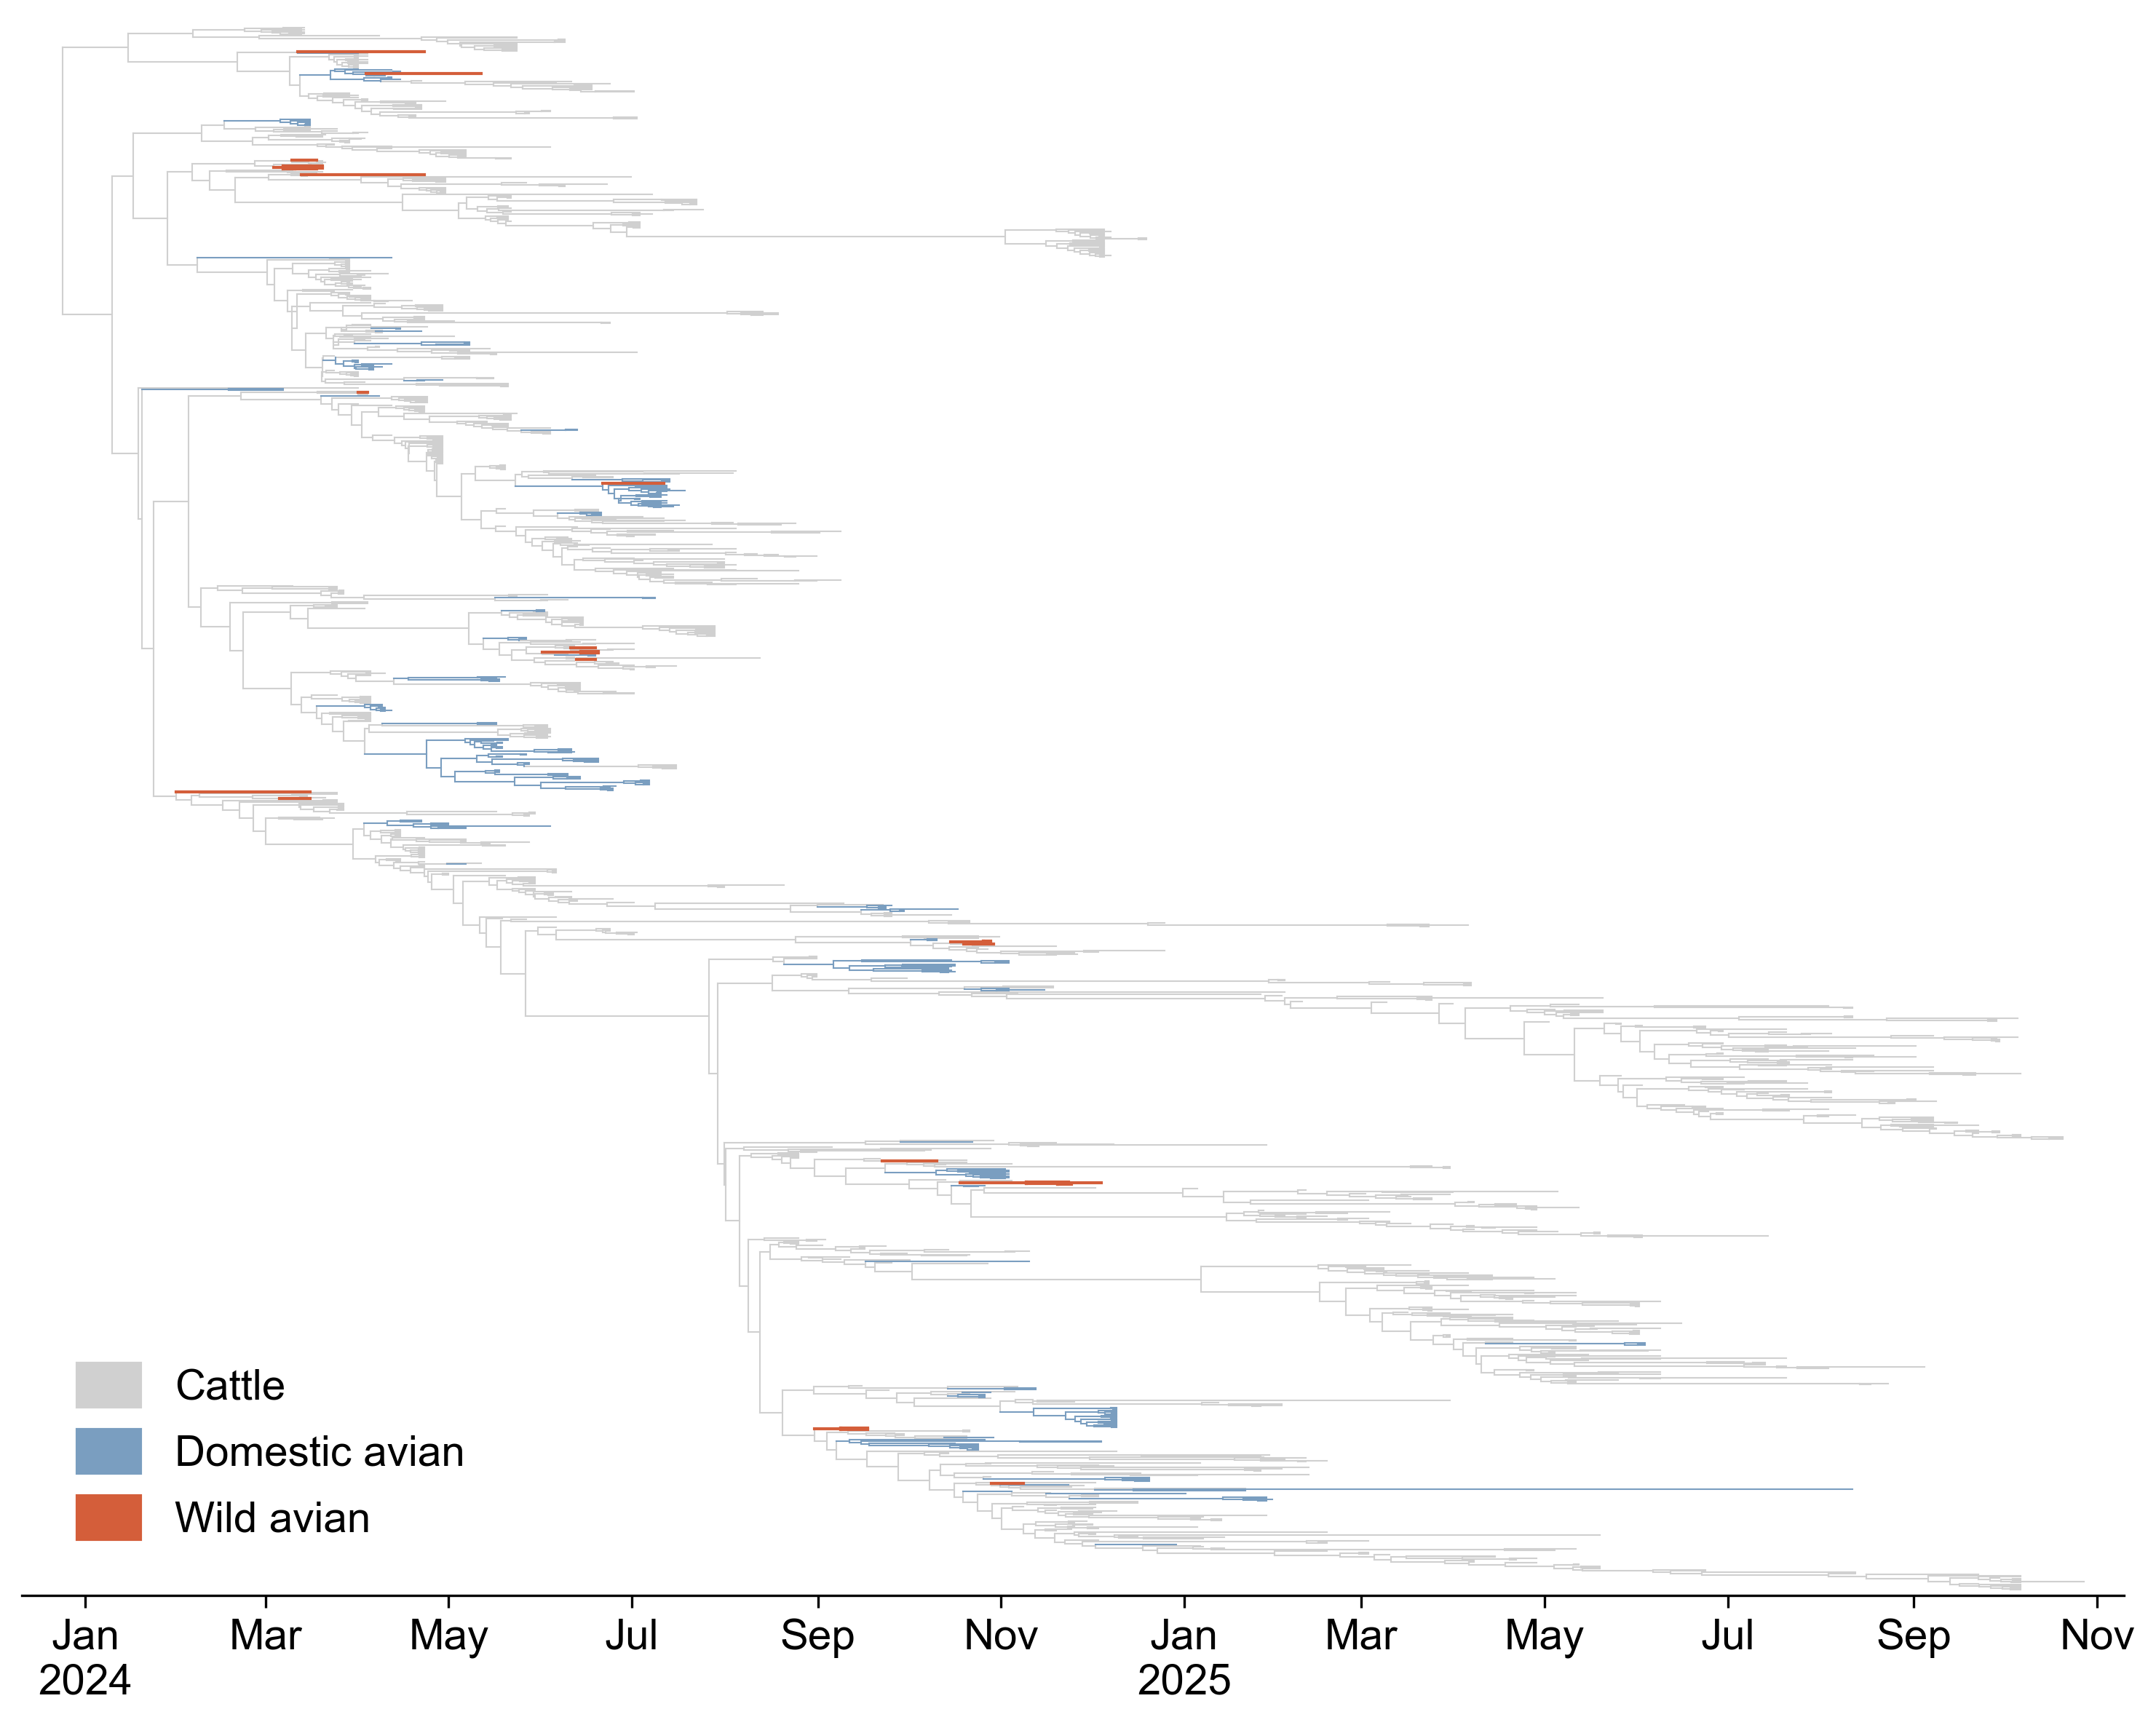

In [4]:
# myTree = bt.loadNexus(str(HIPSTR_TREE), absoluteTime=False)
# myTree.traverse_tree()
# myTree.drawTree()

# origin_date = get_origin_date(myTree)
# h2d = height_to_date(myTree, origin_date)

# fig, ax = plt.subplots(figsize=(10, 12), facecolor="white")

# myTree.plotTree(ax,
#                 x_attr=lambda k: h2d(k.height),
#                 colour=lambda k: STATE_COLORS.get(k.traits.get("host.rate", ""), "#999999"),
#                 width=1)

# max_y = max(k.y for k in myTree.Objects)
# ax.set_ylim(-5, max_y + 5)

# min_h = min(k.height for k in myTree.Objects)
# max_h = max(k.height for k in myTree.Objects)
# pad = (max_h - min_h) * 0.02
# ax.set_xlim(h2d(min_h - pad), h2d(max_h + pad))

# ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
# plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=13)

# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)
# ax.spines["left"].set_visible(False)
# ax.set_yticks([])

# legend_handles = [
#     mpatches.Patch(color=STATE_COLORS[s], label=STATE_LABELS[s])
#     for s in ["cattle", "domestic_avian", "wild_avian"]
# ]
# ax.legend(handles=legend_handles, loc="upper right", frameon=False,
#           fontsize=14, framealpha=0.9, edgecolor="#cccccc",
#           handlelength=2.0, handleheight=1.5, borderpad=1.0)

# plt.tight_layout()
# # fig.savefig(FIG_DIR / "fig1_basta_phylogeny.pdf", dpi=300, bbox_inches="tight")
# # fig.savefig(FIG_DIR / "fig1_basta_phylogeny.png", dpi=300, bbox_inches="tight")
# # print(f"Saved to {FIG_DIR / 'fig1_basta_phylogeny'}")
# plt.show()
from matplotlib.ticker import FuncFormatter
myTree = bt.loadNexus(str(HIPSTR_TREE), absoluteTime=False)
myTree.traverse_tree()
myTree.drawTree()

origin_date = get_origin_date(myTree)
h2d = height_to_date(myTree, origin_date)

fig, ax = plt.subplots(figsize=(10, 8), facecolor="white")

host_key = lambda k: k.traits.get("host.rate", "")

layers = [
    ("cattle",         "#d0d0d0", 0.5, 1),
    ("domestic_avian", "#7a9ec0", 0.5, 1),
    ("wild_avian",     "#d45e3a", 1, 1.00),
]

for host, color, lw, alpha in layers:
    myTree.plotTree(ax,
                    x_attr=lambda k: h2d(k.height),
                    target=lambda k, h=host: host_key(k) == h,
                    colour=color,
                    width=lw,
                    alpha=alpha)

max_y = max(k.y for k in myTree.Objects)
ax.set_ylim(-5, max_y + 5)

min_h = min(k.height for k in myTree.Objects)
max_h = max(k.height for k in myTree.Objects)
pad = (max_h - min_h) * 0.02
ax.set_xlim(h2d(min_h - pad), h2d(max_h + pad))

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 3, 5, 7, 9, 11]))
ax.xaxis.set_major_formatter(FuncFormatter(
    lambda x, pos: mdates.num2date(x).strftime("%b\n%Y") if mdates.num2date(x).month == 1
    else mdates.num2date(x).strftime("%b")
))
ax.tick_params(axis="x", labelsize=14)

ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_yticks([])
ax.tick_params(axis="x", length=4, width=0.8)
ax.spines["bottom"].set_linewidth(0.8)


legend_handles = [
    mpatches.Patch(color=c, alpha=a, label=STATE_LABELS[h])
    for h, c, _, a in layers
]
ax.legend(handles=legend_handles, loc="lower left", frameon=False,
        fontsize=14, framealpha=0.9, edgecolor="#cccccc",
        handlelength=1.5, handleheight=1.2, borderpad=0.8)

plt.tight_layout()
# plt.savefig(FIG_DIR / "fig1_phylogeny.pdf", dpi=300, bbox_inches="tight")
# plt.savefig(FIG_DIR / "fig1_phylogeny.png", dpi=300, bbox_inches="tight")
# print(f"Saved to {FIG_DIR / 'fig1_phylogeny'}")
plt.show()

# Host transition comparisons

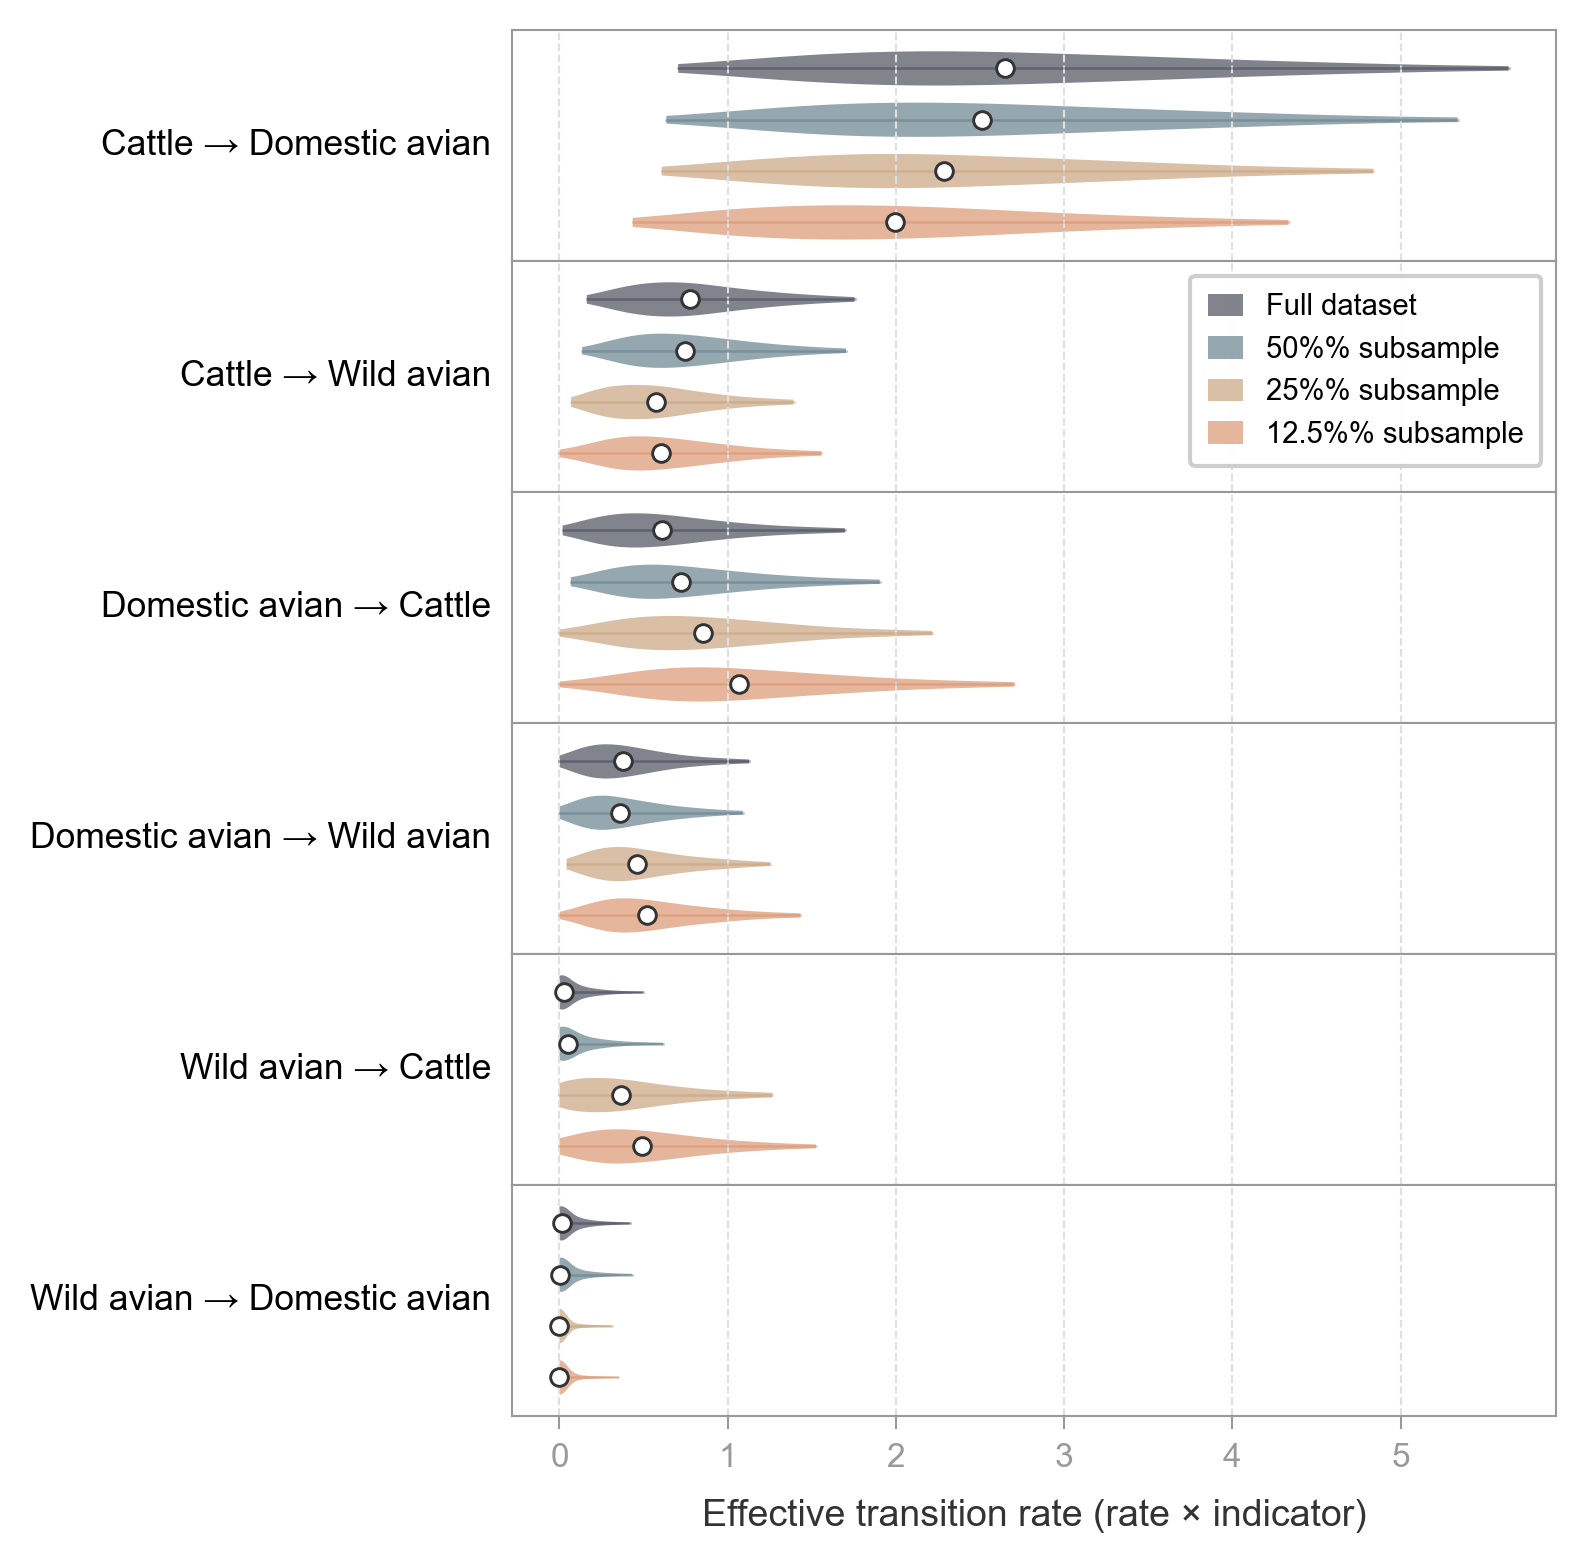

In [5]:
def read_log_file(log_file, burnin=0.1):
    """Read a BEAST log file and return a DataFrame after removing burn-in."""
    df = pd.read_csv(log_file, comment="#", sep="\t")
    burnin_rows = int(len(df) * burnin)
    return df.iloc[burnin_rows:].reset_index(drop=True)

def multiply_columns(df, col1, col2, new_col):
    """Multiply two columns in a DataFrame and store the result in a new column."""
    df[new_col] = df[col1] * df[col2]
    return df

main_log_df = read_log_file(MAIN_1102_LOG)
subsampled_551_df = read_log_file(SUBSAMPLED_551_LOG)
subsampled_275_df = read_log_file(SUBSAMPLED_275_LOG)
subsampled_137_df = read_log_file(SUBSAMPLED_137_LOG)

transitions = ['cattle.domestic_avian', 'cattle.wild_avian', 'domestic_avian.cattle', 'domestic_avian.wild_avian', 'wild_avian.cattle', 'wild_avian.domestic_avian']
# Fix: operate in place (multiply_columns already modifies in place via df[new_col] = ...)
datasets = {
    "Full (1,102 cattle)": main_log_df,
    "551 cattle": subsampled_551_df,
    "275 cattle": subsampled_275_df,
    "137 cattle": subsampled_137_df,
}

for name, df in datasets.items():
    for trans in transitions:
        rate_col = f"host.rates.{trans}"
        indicator_col = f"host.indicators.{trans}"
        new_col = f"{trans}.effective_rate"
        df[new_col] = df[rate_col] * df[indicator_col]

    
# color by subsampling
COLORS = {
    "main": "#1f77b4",  # blue
    "subsampled_551": "#ff7f0e",  # orange
    "subsampled_275": "#2ca02c",  # green
    "subsampled_137": "#d62728",  # red
}

CATEGORIES = [
    ("Cattle \u2192 Domestic avian", "cattle.domestic_avian.effective_rate"),
    ("Cattle \u2192 Wild avian", "cattle.wild_avian.effective_rate"),
    ("Domestic avian \u2192 Cattle", "domestic_avian.cattle.effective_rate"),
    ("Domestic avian \u2192 Wild avian", "domestic_avian.wild_avian.effective_rate"),
    ("Wild avian \u2192 Cattle", "wild_avian.cattle.effective_rate"),
    ("Wild avian \u2192 Domestic avian", "wild_avian.domestic_avian.effective_rate")
]

# Fix: operate in place (multiply_columns already modifies in place via df[new_col] = ...)
datasets = {
    "Full (1,102 cattle)": main_log_df,
    "551 cattle": subsampled_551_df,
    "275 cattle": subsampled_275_df,
    "137 cattle": subsampled_137_df,
}

for name, df in datasets.items():
    for trans in transitions:
        rate_col = f"host.rates.{trans}"
        indicator_col = f"host.indicators.{trans}"
        new_col = f"{trans}.effective_rate"
        df[new_col] = df[rate_col] * df[indicator_col]

COLORS = {
    "Full (1,102 cattle)": "#1f77b4",
    "551 cattle": "#ff7f0e",
    "275 cattle": "#2ca02c",
    "137 cattle": "#d62728",
}

CATEGORIES = [
    ("Cattle → Domestic avian", "cattle.domestic_avian.effective_rate"),
    ("Cattle → Wild avian", "cattle.wild_avian.effective_rate"),
    ("Domestic avian → Cattle", "domestic_avian.cattle.effective_rate"),
    ("Domestic avian → Wild avian", "domestic_avian.wild_avian.effective_rate"),
    ("Wild avian → Cattle", "wild_avian.cattle.effective_rate"),
    ("Wild avian → Domestic avian", "wild_avian.domestic_avian.effective_rate"),
]

from scipy.stats import gaussian_kde

def hpd_interval(samples, credible_mass=0.95):
    sorted_samples = np.sort(samples)
    n = len(sorted_samples)
    interval_size = int(np.ceil(credible_mass * n))
    widths = sorted_samples[interval_size:] - sorted_samples[:n - interval_size]
    best = np.argmin(widths)
    return sorted_samples[best], sorted_samples[best + interval_size]

COLORS = {
    "Full (1,102 cattle)": "#2d3142",
    "551 cattle": "#4f6d7a",
    "275 cattle": "#c0956b",
    "137 cattle": "#d4845a",
}

level_names = list(datasets.keys())
n_levels = len(level_names)
violin_half_width = 0.2
spacing = 0.6
offsets = [(i - (n_levels - 1) / 2) * spacing for i in range(n_levels)]

fig, axes = plt.subplots(len(CATEGORIES), 1, figsize=(6, 6),
                        sharex=True, gridspec_kw={"hspace": 0})

for row, (ax, (label, col)) in enumerate(zip(axes, CATEGORIES)):
    for j, level in enumerate(level_names[::-1]):
        df = datasets[level]
        vals = df[col].values
        pos = offsets[j]
        color = COLORS[level]
        med = np.median(vals)

        if np.max(vals) == 0 or np.std(vals) < 1e-8:
            ax.scatter(med, pos, s=20, color="white", edgecolors=color,
                        linewidths=1.0, zorder=5)
            continue

        hpd_lo, hpd_hi = hpd_interval(vals)

        kde = gaussian_kde(vals, bw_method=0.3)
        x_grid = np.linspace(hpd_lo, hpd_hi, 300)
        density = kde(x_grid)
        density = density / density.max() * violin_half_width

        ax.fill_between(x_grid, pos - density, pos + density,
                        facecolor=color, alpha=0.6,
                        edgecolor="none")
        ax.plot([hpd_lo, hpd_hi], [pos, pos], color=color,
                linewidth=0.6, alpha=0.4, zorder=3)
        ax.scatter(med, pos, s=18, color="white", edgecolors="#333333",
                    linewidths=0.7, zorder=6)
        

    y_lo = offsets[0] - violin_half_width - 0.25
    y_hi = offsets[-1] + violin_half_width + 0.25
    ax.set_ylim(y_lo, y_hi)
    ax.set_yticks([])

    ax.text(-0.02, 0.5, label, transform=ax.transAxes, fontsize=8.5,
            ha="right", va="center", fontweight="medium")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color("#999999")

    ax.tick_params(axis="x", length=3, width=0.5, colors="#999999",
                    labelsize=8)
    ax.tick_params(axis="y", length=0)

    if row < len(CATEGORIES) - 1:
        ax.tick_params(axis="x", labelbottom=False)

    ax.set_facecolor("white")
    
    # add gridlines
    ax.xaxis.grid(True, color="#e0e0e0", linestyle="--", linewidth=0.5)

axes[-1].set_xlabel("Effective transition rate (rate × indicator)",
                    fontsize=9, color="#333333", labelpad=6)

legend_handles = [mpatches.Patch(facecolor=COLORS[l], alpha=0.6,
                                edgecolor="none", label=l)
                for l in level_names]
legend_labels = ['Full dataset', '50%% subsample', '25%% subsample', '12.5%% subsample']
axes[1].legend(handles=legend_handles, labels=legend_labels, loc="upper right", fontsize=7,
                frameon=True, framealpha=0.95, edgecolor="#cccccc",
                borderpad=0.6, handlelength=1.2, handleheight=0.8)

fig.patch.set_facecolor("white")
plt.subplots_adjust(left=0.32)
plt.show()




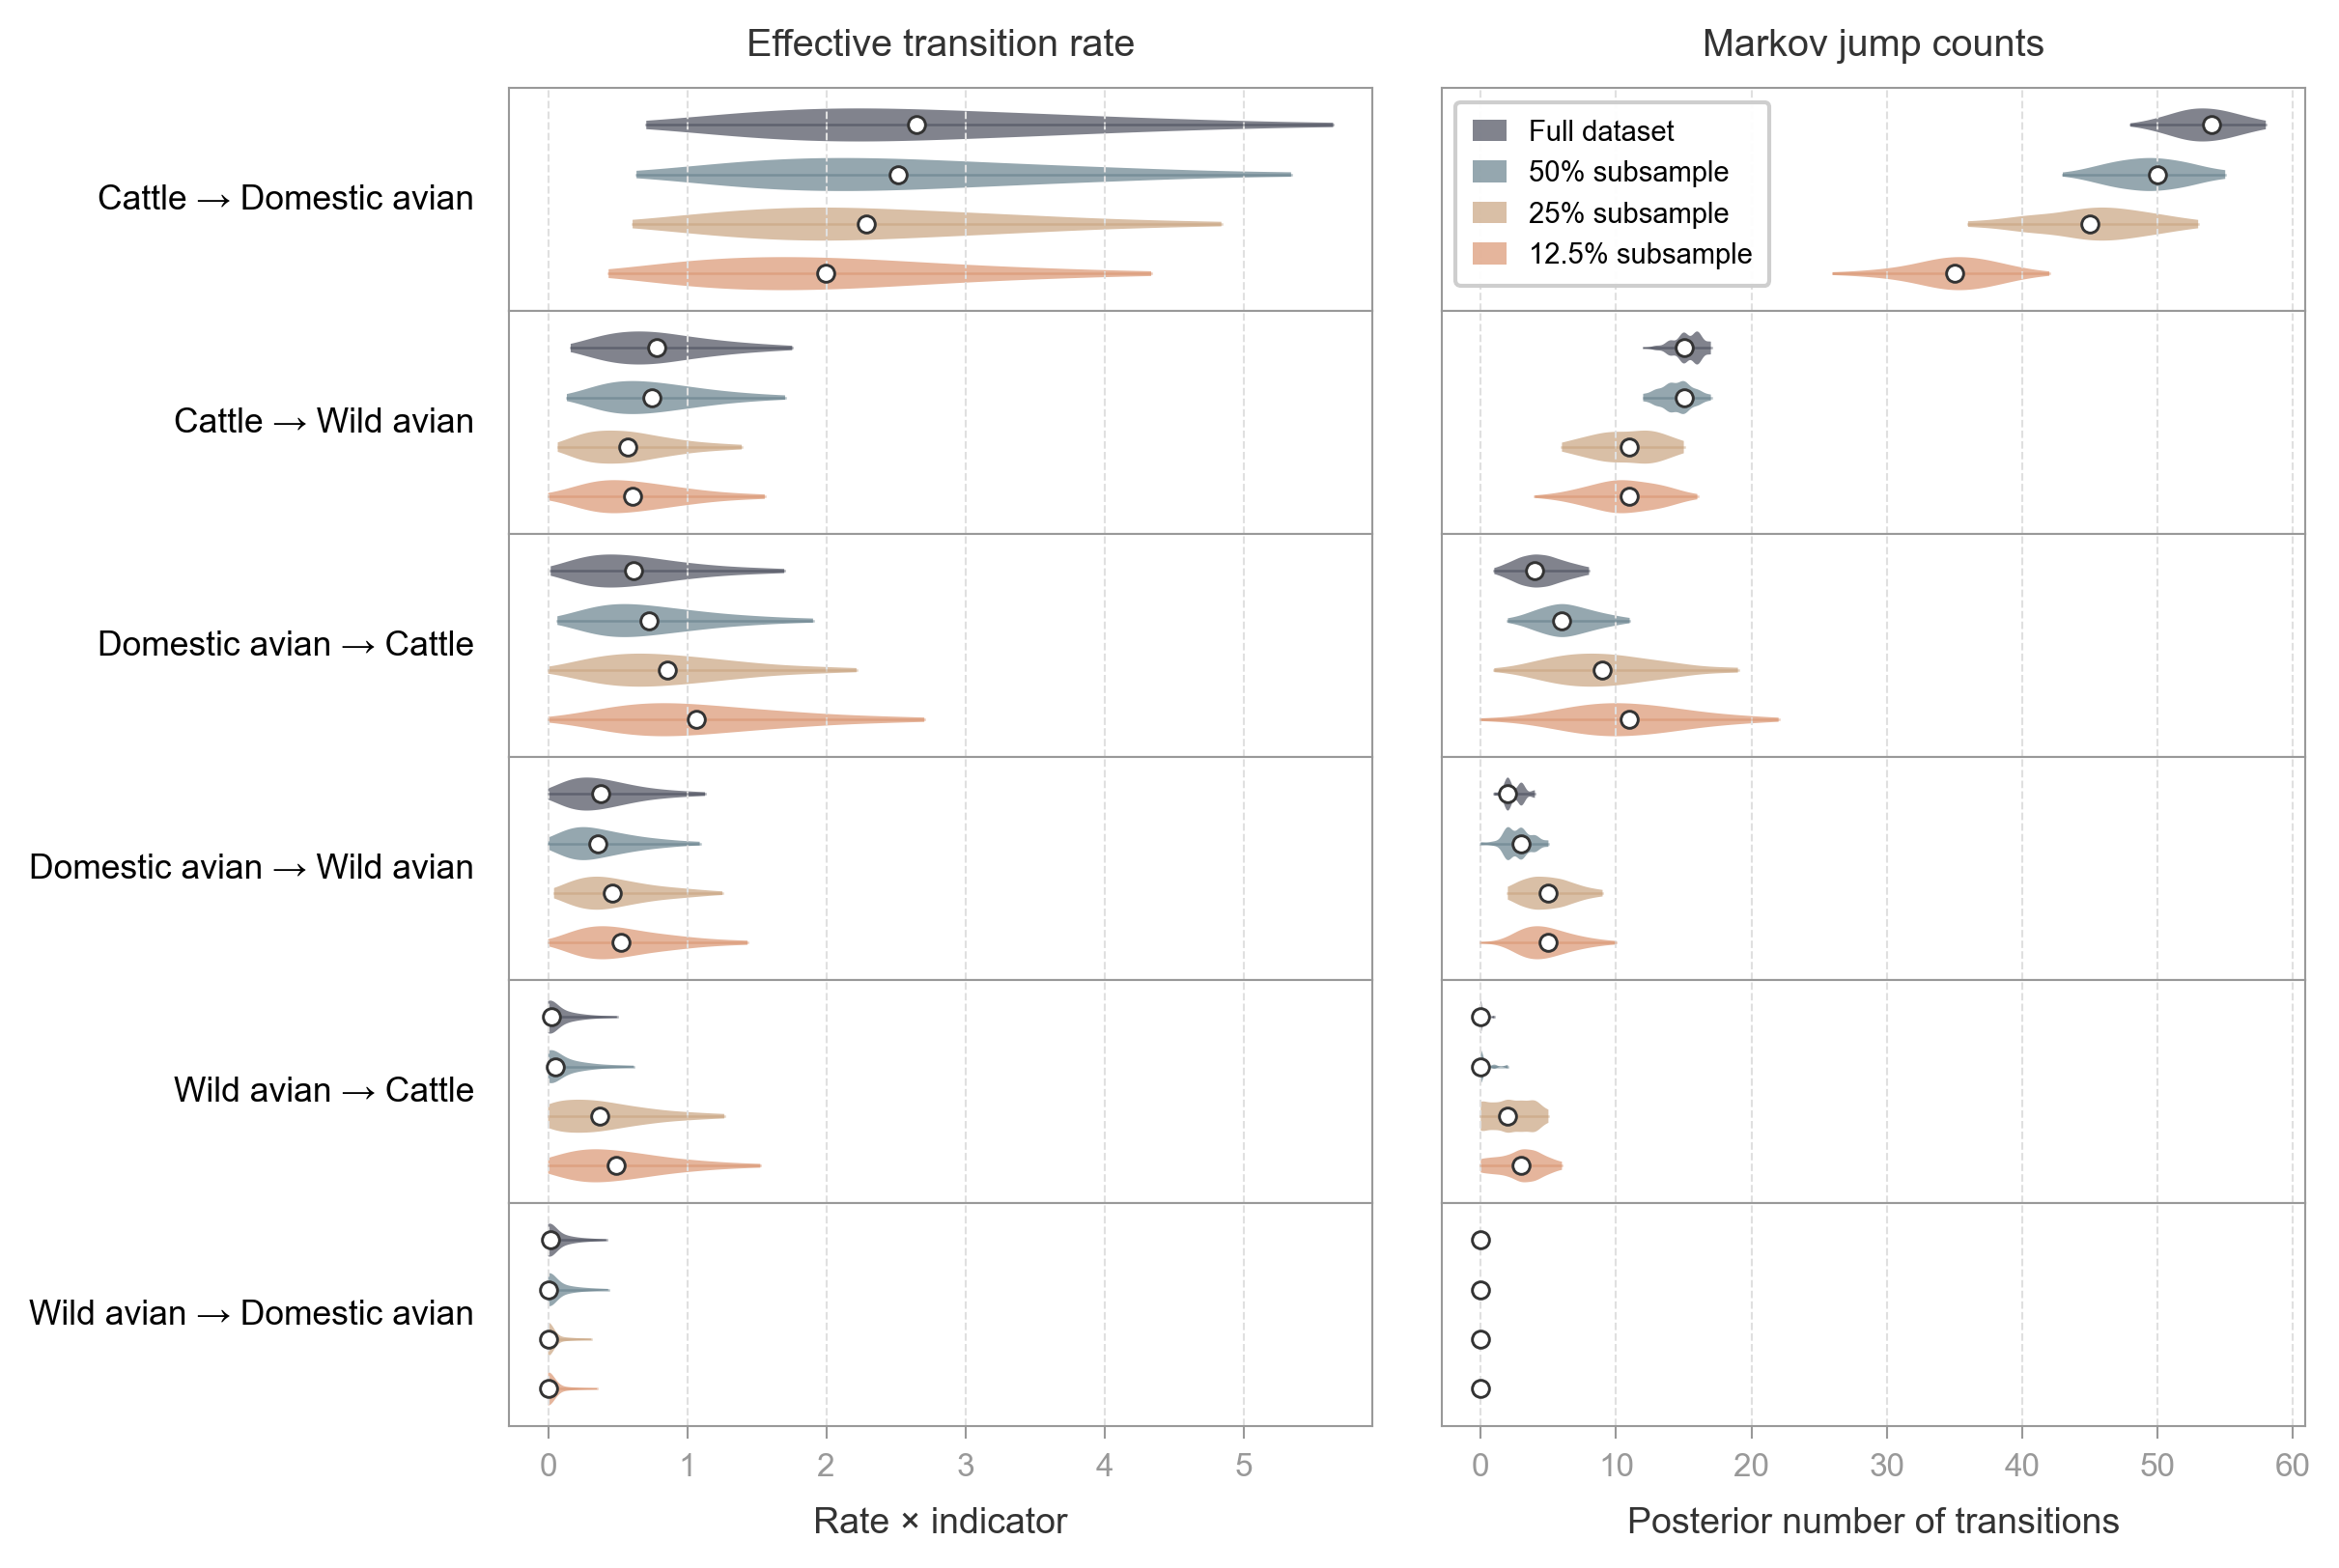

In [6]:
import re
from collections import Counter
from scipy.stats import gaussian_kde

def hpd_interval(samples, credible_mass=0.95):
    sorted_samples = np.sort(samples)
    n = len(sorted_samples)
    interval_size = int(np.ceil(credible_mass * n))
    widths = sorted_samples[interval_size:] - sorted_samples[:n - interval_size]
    best = np.argmin(widths)
    return sorted_samples[best], sorted_samples[best + interval_size]

def parse_jump_history(log_file, burnin=0.1):
    transition_types = [
        'cattle.domestic_avian', 'cattle.wild_avian',
        'domestic_avian.cattle', 'domestic_avian.wild_avian',
        'wild_avian.cattle', 'wild_avian.domestic_avian',
    ]
    counts = {t: [] for t in transition_types}
    rows = []
    with open(log_file) as f:
        for line in f:
            if line.startswith('#') or line.startswith('state'):
                continue
            rows.append(line.strip())
    burnin_rows = int(len(rows) * burnin)
    rows = rows[burnin_rows:]
    jump_pattern = re.compile(r'\{1,[\d.]+,(\w+),(\w+)\}')
    for row in rows:
        parts = row.split('\t')
        history = parts[2] if len(parts) > 2 else ''
        jumps = jump_pattern.findall(history)
        row_counts = Counter()
        for fs, ts in jumps:
            row_counts[f"{fs}.{ts}"] += 1
        for t in transition_types:
            counts[t].append(row_counts.get(t, 0))
    return {t: np.array(v) for t, v in counts.items()}

# Parse jump histories
HIST_DIR = Path("...")  # update to your FIT directory
jump_datasets = {
    "Full (1,102 cattle)": parse_jump_history(MAIN_1102_JUMPS_LOG),
    "551 cattle": parse_jump_history(SUBSAMPLED_551_JUMPS_LOG),
    "275 cattle": parse_jump_history(SUBSAMPLED_275_JUMPS_LOG),
    "137 cattle": parse_jump_history(SUBSAMPLED_137_JUMPS_LOG),
}

CATEGORIES = [
    ("Cattle → Domestic avian", "cattle.domestic_avian"),
    ("Cattle → Wild avian", "cattle.wild_avian"),
    ("Domestic avian → Cattle", "domestic_avian.cattle"),
    ("Domestic avian → Wild avian", "domestic_avian.wild_avian"),
    ("Wild avian → Cattle", "wild_avian.cattle"),
    ("Wild avian → Domestic avian", "wild_avian.domestic_avian"),
]

COLORS = {
    "Full (1,102 cattle)": "#2d3142",
    "551 cattle": "#4f6d7a",
    "275 cattle": "#c0956b",
    "137 cattle": "#d4845a",
}

level_names = list(jump_datasets.keys())
n_levels = len(level_names)
violin_half_width = 0.2
spacing = 0.6
offsets = [(i - (n_levels - 1) / 2) * spacing for i in range(n_levels)]

fig = plt.figure(figsize=(10, 6), facecolor="white")
gs = fig.add_gridspec(len(CATEGORIES), 2, hspace=0, wspace=0.08)

axarr = np.empty((len(CATEGORIES), 2), dtype=object)
for row in range(len(CATEGORIES)):
    for col in range(2):
        share = axarr[0, col] if row > 0 else None
        axarr[row, col] = fig.add_subplot(gs[row, col], sharex=share)

    
for row, (label, key) in enumerate(CATEGORIES):
    ax_left = axarr[row, 0]
    ax_right = axarr[row, 1]

    for panel, (ax, get_vals) in enumerate([
        (ax_left, lambda level: datasets[level][f"{key}.effective_rate"].values),
        (ax_right, lambda level: jump_datasets[level][key]),
    ]):
        for j, level in enumerate(level_names[::-1]):
            vals = get_vals(level)
            pos = offsets[j]
            color = COLORS[level]
            med = np.median(vals)

            if np.max(vals) == 0 or np.std(vals) < 1e-8:
                ax.scatter(med, pos, s=20, color="white", edgecolors=color,
                            linewidths=1.0, zorder=5)
                continue

            hpd_lo, hpd_hi = hpd_interval(vals)

            kde = gaussian_kde(vals, bw_method=0.3)
            x_grid = np.linspace(hpd_lo, hpd_hi, 300)
            density = kde(x_grid)
            density = density / density.max() * violin_half_width

            ax.fill_between(x_grid, pos - density, pos + density,
                            facecolor=color, alpha=0.6, edgecolor="none")
            ax.plot([hpd_lo, hpd_hi], [pos, pos], color=color,
                    linewidth=0.6, alpha=0.4, zorder=3)
            ax.scatter(med, pos, s=18, color="white", edgecolors="#333333",
                        linewidths=0.7, zorder=6)

        y_lo = offsets[0] - violin_half_width - 0.25
        y_hi = offsets[-1] + violin_half_width + 0.25
        ax.set_ylim(y_lo, y_hi)
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.5)
            spine.set_color("#999999")

        ax.tick_params(axis="x", length=3, width=0.5, colors="#999999", labelsize=8)
        ax.tick_params(axis="y", length=0)
        ax.set_facecolor("white")
        ax.xaxis.grid(True, color="#e0e0e0", linestyle="--", linewidth=0.5)

        if row < len(CATEGORIES) - 1:
            ax.tick_params(axis="x", labelbottom=False)

    # Y-labels on left panel only
    ax_left.text(-0.04, 0.5, label, transform=ax_left.transAxes, fontsize=8.5,
                ha="right", va="center", fontweight="medium")

# Column titles
axarr[0, 1].set_title("Markov jump counts", fontsize=9.5, color="#333333", pad=8)
axarr[0, 0].set_title("Effective transition rate", fontsize=9.5,
                        color="#333333", pad=8)

# X-axis labels on bottom row only
axarr[-1, 1].set_xlabel("Posterior number of transitions", fontsize=9,
                        color="#333333", labelpad=6)
axarr[-1, 0].set_xlabel("Rate × indicator", fontsize=9,
                        color="#333333", labelpad=6)

# Legend on top-right panel
legend_labels = ['Full dataset', '50% subsample', '25% subsample', '12.5% subsample']
legend_handles = [mpatches.Patch(facecolor=COLORS[l], alpha=0.6, edgecolor="none")
                for l in level_names]
axarr[0, 1].legend(handles=legend_handles, labels=legend_labels, loc="upper left",
                    fontsize=7, frameon=True, framealpha=0.95, edgecolor="#cccccc",
                    borderpad=0.6, handlelength=1.2, handleheight=0.8)

fig.patch.set_facecolor("white")
plt.subplots_adjust(left=0.28)
plt.show()


Cattle→
Domestic avian cattle.domestic_avian
Cattle→
Wild avian cattle.wild_avian
Domestic avian→
Cattle domestic_avian.cattle
Domestic avian→
Wild avian domestic_avian.wild_avian
Wild avian→
Cattle wild_avian.cattle
Wild avian→
Domestic avian wild_avian.domestic_avian


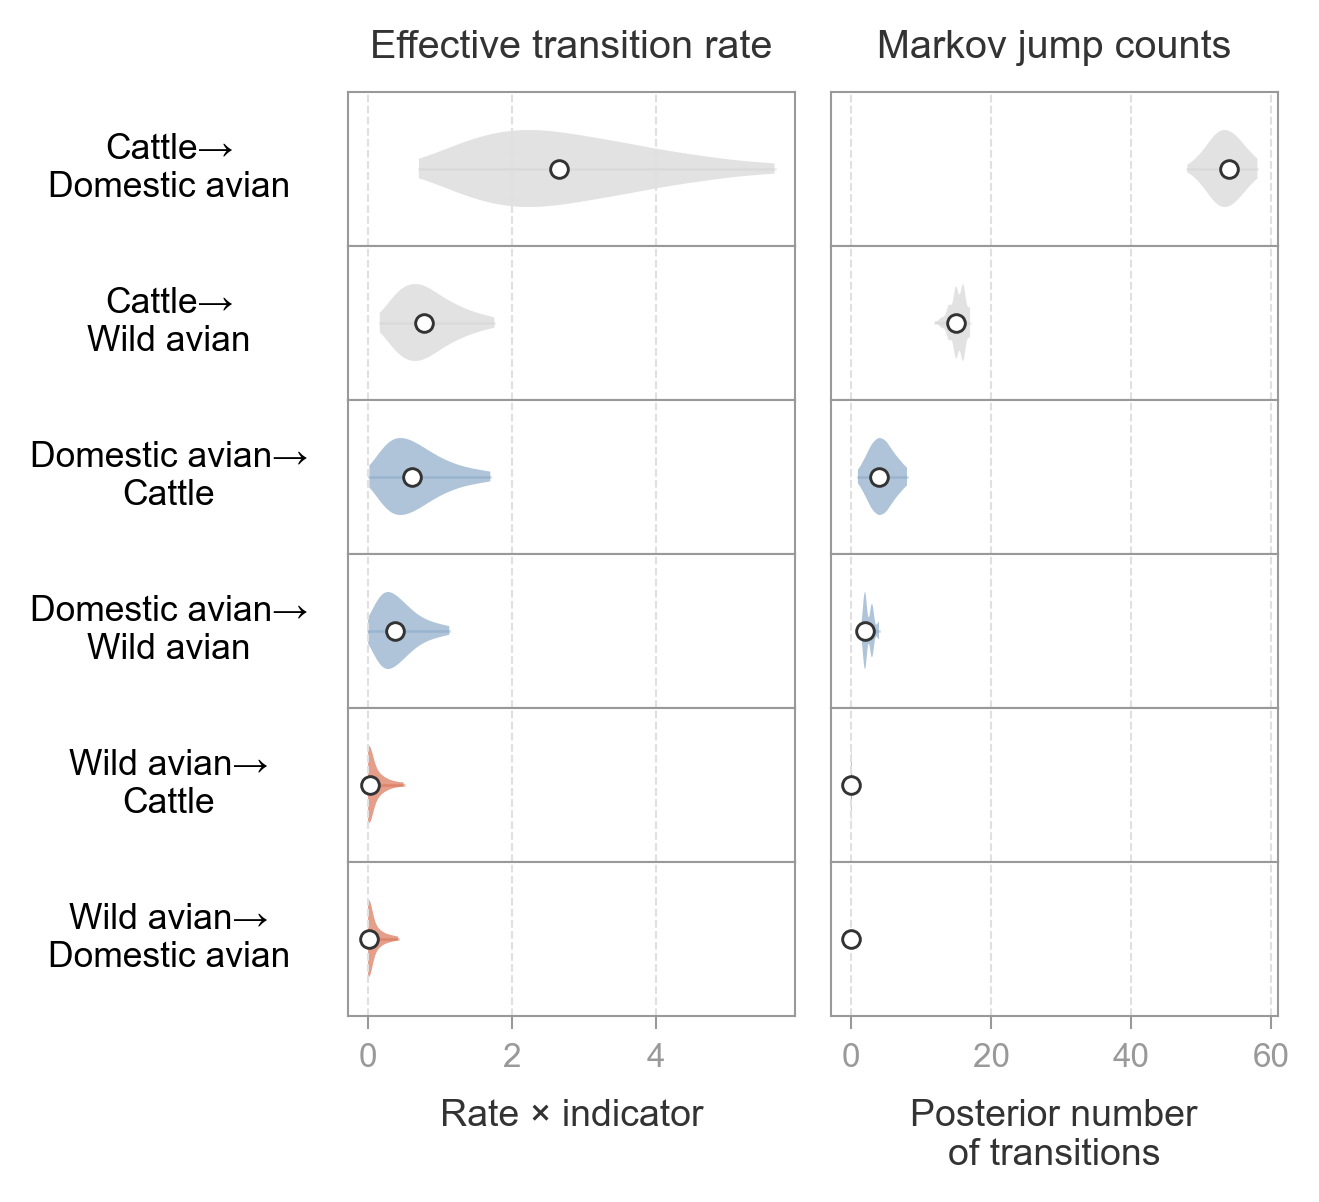

In [7]:
import re
from collections import Counter
from scipy.stats import gaussian_kde

def hpd_interval(samples, credible_mass=0.95):
    sorted_samples = np.sort(samples)
    n = len(sorted_samples)
    interval_size = int(np.ceil(credible_mass * n))
    widths = sorted_samples[interval_size:] - sorted_samples[:n - interval_size]
    best = np.argmin(widths)
    return sorted_samples[best], sorted_samples[best + interval_size]

def parse_jump_history(log_file, burnin=0.1):
    transition_types = [
        'cattle.domestic_avian', 'cattle.wild_avian',
        'domestic_avian.cattle', 'domestic_avian.wild_avian',
        'wild_avian.cattle', 'wild_avian.domestic_avian',
    ]
    counts = {t: [] for t in transition_types}
    rows = []
    with open(log_file) as f:
        for line in f:
            if line.startswith('#') or line.startswith('state'):
                continue
            rows.append(line.strip())
    burnin_rows = int(len(rows) * burnin)
    rows = rows[burnin_rows:]
    jump_pattern = re.compile(r'\{1,[\d.]+,(\w+),(\w+)\}')
    for row in rows:
        parts = row.split('\t')
        history = parts[2] if len(parts) > 2 else ''
        jumps = jump_pattern.findall(history)
        row_counts = Counter()
        for fs, ts in jumps:
            row_counts[f"{fs}.{ts}"] += 1
        for t in transition_types:
            counts[t].append(row_counts.get(t, 0))
    return {t: np.array(v) for t, v in counts.items()}

# Parse jump history — full dataset only
jump_data = parse_jump_history(MAIN_1102_JUMPS_LOG)

CATEGORIES = [
    ("Cattle→\nDomestic avian", "cattle.domestic_avian"),
    ("Cattle→\nWild avian", "cattle.wild_avian"),
    ("Domestic avian→\nCattle", "domestic_avian.cattle"),
    ("Domestic avian→\nWild avian", "domestic_avian.wild_avian"),
    ("Wild avian→\nCattle", "wild_avian.cattle"),
    ("Wild avian→\nDomestic avian", "wild_avian.domestic_avian"),
]

COLOR = "#c0956b"
violin_half_width = 0.25

colors = [
    ("cattle",         "#d0d0d0", 0.5, 1),
    ("domestic_avian", "#7a9ec0", 0.5, 1),
    ("wild_avian",     "#d45e3a", 1, 1.00),
]

fig = plt.figure(figsize=(5, 4), facecolor="white")
gs = fig.add_gridspec(len(CATEGORIES), 2, hspace=0, wspace=0.08)

axarr = np.empty((len(CATEGORIES), 2), dtype=object)
for row in range(len(CATEGORIES)):
    for col in range(2):
        share = axarr[0, col] if row > 0 else None
        axarr[row, col] = fig.add_subplot(gs[row, col], sharex=share)

for row, (label, key) in enumerate(CATEGORIES):
    print(label, key)
    source = key.split('.')[0]
    COLOR = next(c for s, c, _, _ in colors if s == source)
    
    ax_left = axarr[row, 0]
    ax_right = axarr[row, 1]

    for ax, vals in [
        (ax_left, datasets["Full (1,102 cattle)"][f"{key}.effective_rate"].values),
        (ax_right, jump_data[key]),
    ]:
        pos = 0
        med = np.median(vals)

        if np.max(vals) == 0 or np.std(vals) < 1e-8:
            ax.scatter(med, pos, s=20, color="white", edgecolors=COLOR,
                        linewidths=1.0, zorder=5)
        else:
            hpd_lo, hpd_hi = hpd_interval(vals)
            kde = gaussian_kde(vals, bw_method=0.3)
            x_grid = np.linspace(hpd_lo, hpd_hi, 300)
            density = kde(x_grid)
            density = density / density.max() * violin_half_width

            ax.fill_between(x_grid, pos - density, pos + density,
                            facecolor=COLOR, alpha=0.6, edgecolor="none")
            ax.plot([hpd_lo, hpd_hi], [pos, pos], color=COLOR,
                    linewidth=0.6, alpha=0.4, zorder=3)
            ax.scatter(med, pos, s=18, color="white", edgecolors="#333333",
                        linewidths=0.7, zorder=6)

        ax.set_ylim(-0.5, 0.5)
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.5)
            spine.set_color("#999999")

        ax.tick_params(axis="x", length=3, width=0.5, colors="#999999", labelsize=8)
        ax.tick_params(axis="y", length=0)
        ax.set_facecolor("white")
        ax.xaxis.grid(True, color="#e0e0e0", linestyle="--", linewidth=0.5)

        if row < len(CATEGORIES) - 1:
            ax.tick_params(axis="x", labelbottom=False)

    ax_left.text(-0.4, 0.5, label, transform=ax_left.transAxes, fontsize=8.5,
                ha="center", va="center", fontweight="medium")

axarr[0, 1].set_title("Markov jump counts", fontsize=9.5, color="#333333", pad=8)
axarr[0, 0].set_title("Effective transition rate", fontsize=9.5, color="#333333", pad=8)
axarr[-1, 1].set_xlabel("Posterior number\nof transitions", fontsize=9, color="#333333", labelpad=6)
axarr[-1, 0].set_xlabel("Rate × indicator", fontsize=9, color="#333333", labelpad=6)

fig.patch.set_facecolor("white")
plt.subplots_adjust(left=0.28)
# plt.savefig(FIG_DIR / "fig1_transition_rates.pdf", dpi=300, bbox_inches="tight")
# plt.savefig(FIG_DIR / "fig1_transition_rates.png", dpi=300, bbox_inches="tight")
# print(f"Saved to {FIG_DIR / 'fig1_transition_rates'}")
plt.show()

In [9]:
def make_table(datasets, jump_datasets, transitions):
    table_rate_data = []
    table_jump_data = []
    for level in datasets.keys():
        rate_row = [level]
        jump_row = [level]
        for trans in transitions:
            eff_rate_col = f"{trans}.effective_rate"
            eff_rate_median = np.median(datasets[level][eff_rate_col].values)
            hpd_lo, hpd_hi = hpd_interval(datasets[level][eff_rate_col].values, credible_mass=0.95)
            jump_median = np.median(jump_datasets[level][trans])
            jump_hpd_lo, jump_hpd_hi = hpd_interval(jump_datasets[level][trans], credible_mass=0.95)
            rate_row.append(f"{eff_rate_median:.2f} ({hpd_lo:.2f}-{hpd_hi:.2f})")
            jump_row.append(f"{jump_median:.1f} ({jump_hpd_lo:.1f}-{jump_hpd_hi:.1f})")
        table_rate_data.append(rate_row)
        table_jump_data.append(jump_row)
    
    eff_rate_df = pd.DataFrame(table_rate_data, columns=["Dataset"] + [f"{trans}".replace("_", " ").replace(".", "\u2192") for trans in transitions]).T
    eff_rate_df.columns = eff_rate_df.iloc[0]
    eff_rate_df = eff_rate_df[1:]
    jump_df = pd.DataFrame(table_jump_data, columns=["Dataset"] + [f"{trans}".replace("_", " ").replace(".", "\u2192") for trans in transitions]).T
    jump_df.columns = jump_df.iloc[0]
    jump_df = jump_df[1:]
    return eff_rate_df, jump_df


eff_rate_df, jump_df = make_table(datasets, jump_datasets, transitions)

jump_df

Dataset,"Full (1,102 cattle)",551 cattle,275 cattle,137 cattle
cattle→domestic avian,54.0 (48.0-58.0),50.0 (43.0-55.0),45.0 (36.0-53.0),35.0 (26.0-42.0)
cattle→wild avian,15.0 (12.0-17.0),15.0 (12.0-17.0),11.0 (6.0-15.0),11.0 (4.0-16.0)
domestic avian→cattle,4.0 (1.0-8.0),6.0 (2.0-11.0),9.0 (1.0-19.0),11.0 (0.0-22.0)
domestic avian→wild avian,2.0 (1.0-4.0),3.0 (0.0-5.0),5.0 (2.0-9.0),5.0 (0.0-10.0)
wild avian→cattle,0.0 (0.0-1.0),0.0 (0.0-2.0),2.0 (0.0-5.0),3.0 (0.0-6.0)
wild avian→domestic avian,0.0 (0.0-0.0),0.0 (0.0-0.0),0.0 (0.0-0.0),0.0 (0.0-0.0)
